# Customer Segmentation & Churn Pattern Analytics in European Banking

### Project Objectives 

This project analyses customer churn pattern in European banking using customer demographic, financial and engagement data.

The analysis aims to:

- Measure the overall cutomer churn rate
- Identify churn distribution across segements
- Compare churn behaviour across European regions

## Secondary Objectives

The objectives are to:

- Understand the churn among high value customers
- Evaluate engagement and tenure patterns 
- Support strategic planning and marketing decision

## 1. Data Ingestion and Validation 

This section focuses on loading the banking customer dataset and validating the key variables required for customer segmentation and churn analysis. 

The validation process ensures that the dataset is structurally suitable for subsequent data cleaning, segmentation and churn analysis. 

### 1.1 Load Dataset

The first step is to load the European banking customer datset into a pandas Dataframe.

The dataset will be stored in the variable 'df', which will be used throughout the analysis. 

In [2]:
#Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import sklearn

print("Pandas:", pd.__version__)
print("Numpy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Environment is ready!")


Pandas: 3.0.5
Numpy: 2.5.2
Scikit-learn: 1.9.0
Environment is ready!


In [3]:
file_path = "../data/raw/European_Bank.csv"

df = pd.read_csv(file_path)

df.head()


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Check the Dataset Dimensions

print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")

Number of rows: 10,000
Number of columns: 14


### 1.2 Validate Engagement and Product fields 

The dataset cintains variables representing customer product ownership and engagement. These fields are validated to ensure that their obsereved values are within the expected ranges and can be reliably used in subsequent churn analysis.

The variables examined are: 

- 'NumOfProducts': number of banking products held by the customer
- 'HasCrCard': credit card ownership idicator 
- 'IsActiveMember': customer activity indicator

In [5]:
# Inspect unique values in engagement and product fields

print("NumOfProducts:", sorted(df["NumOfProducts"].unique()))
print("HasCrCard:", sorted(df["HasCrCard"].unique()))
print("IsActiveMember:", sorted(df["IsActiveMember"].unique()))

NumOfProducts: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
HasCrCard: [np.int64(0), np.int64(1)]
IsActiveMember: [np.int64(0), np.int64(1)]


In [6]:
# Examine the frequency of each value

print("NumOfProducts distribution:")
print(df["NumOfProducts"].value_counts().sort_index())

print("\nHasCrCard distribution:")
print(df["HasCrCard"].value_counts().sort_index())

print("\nIsActiveMember distribution:")
print(df["IsActiveMember"].value_counts().sort_index())

NumOfProducts distribution:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

HasCrCard distribution:
HasCrCard
0    2945
1    7055
Name: count, dtype: int64

IsActiveMember distribution:
IsActiveMember
0    4849
1    5151
Name: count, dtype: int64


### 1.3 Ensure Binary Variables Consistency

Binary variables should contain only two valid states, represented by 0 and 1. These variables are checked to ensure that no unexpected values are present before they are used in churn and customer segmentation analysis.

In [7]:
# Check the unique values of all binary variables

binary_columns = ["HasCrCard", "IsActiveMember", "Exited"]

for column in binary_columns:
    print(f"{column}: {sorted(df[column].unique())}")

HasCrCard: [np.int64(0), np.int64(1)]
IsActiveMember: [np.int64(0), np.int64(1)]
Exited: [np.int64(0), np.int64(1)]


In [8]:
# Verify that binary variables only contain 0 and 1

for column in binary_columns:
    invalid_values = df.loc[~df[column].isin([0, 1]), column]

    print(f"{column} - Invalid values: {len(invalid_values)}")

HasCrCard - Invalid values: 0
IsActiveMember - Invalid values: 0
Exited - Invalid values: 0


### 1.4 Confirm Churn Labelling Accuracy 

The Exited vairble represents the cutomer churn outcome, where 0 indidcates a retained customer and 1 indicates a churned customer. The distribution of these labels is examined to confirm that both customer outcomes are present and that the churn variable is suitable for subsequent analysis.

In [9]:
# Examine the churn lables

print("Exited value counts:")
print((df["Exited"].value_counts().sort_index()))

Exited value counts:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [10]:
# Calculate retained and churned customer percentages

churn_distribution = df["Exited"].value_counts(normalize=True) * 100

print(f"Retained customers (0): {churn_distribution[0]:.2f}%")
print(f"Churned customers (1): {churn_distribution[1]:.2f}%")

Retained customers (0): 79.63%
Churned customers (1): 20.37%


In [11]:
# Calculate overall churn rate

overall_churn_rate = df["Exited"].mean() * 100

print(f"Overall churn rate: {overall_churn_rate:.2f}%")

Overall churn rate: 20.37%


# 2. Data Cleaning and Preparation

### 2.1 Remove non-analytical fields (Surname)

The Surname variable is a customer-identifying field and does not provide meaningful information for segmentation or churn analysis. It is therefore removed from the analytical dataset while preserving the original dataframe for reference.

In [12]:
# Create a cleaned analytical dataset by removing Surname

df_clean = df.drop(columns=["Surname"])

print(("Original dataset shape:", df.shape))
print("Cleaned dataset shape:", df_clean.shape)

('Original dataset shape:', (10000, 14))
Cleaned dataset shape: (10000, 13)


In [13]:
# Verify the remaining columns

print("Remaining columns:")
print(df_clean.columns.tolist())

Remaining columns:
['Year', 'CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


### 2.2 Convert categorical variables for grouping

The Geography and Gender variables represent categorical customer characteristics. These variables are converted to categorical data types to ensure consistent grouping and analysis in subsequent stages.

In [14]:
# Convert categorical varibles to categorical data type

categorical_columns = ["Geography", "Gender"]

for column in categorical_columns:
    df_clean[column] =df_clean[column].astype("category")

print(df_clean[categorical_columns].dtypes)

Geography    category
Gender       category
dtype: object


In [15]:
# Display the available categories

for column in categorical_columns:
    print(f"\n{column} categories:")
    print(df_clean[column].cat.categories.tolist())


Geography categories:
['France', 'Germany', 'Spain']

Gender categories:
['Female', 'Male']


### 2.3 Create Derived Segmentation Fields

Derived segmentation variables are created from customers' demographic and financial characteristics. These fields group customers into meaningful categories that will be used to compare churn behaviour across different customer segments.

The segmentation variables are:

- Age: Under 30, 30–45, 46–60, 60+
- Credit Score: Low, Medium, High
- Tenure: New, Mid-term, Long-term
- Balance: Zero Balance, Low Balance, High Balance

Geography is already available as a categorical variable with the three required regions: France, Germany, and Spain.

The original numerical variables are retained so that both detailed numerical analysis and grouped segmentation can be performed.

In [16]:
# Create age segmentation

df_clean["AgeSegment"] = pd.cut(
    df_clean["Age"],
    bins=[0, 29, 45, 60, np.inf],
    labels=["Under 30", "30-45", "46-60", "60+"]
)

print(df_clean["AgeSegment"].value_counts().sort_index())

AgeSegment
Under 30    1641
30-45       6248
46-60       1647
60+          464
Name: count, dtype: int64


In [17]:
# Create credit score segmentation (We are using the FICO credit score ranges to segment customers into low, medium, and high credit score categories.)
print(df["CreditScore"].describe())

df_clean["CreditScoreSegment"] = pd.cut(
    df_clean["CreditScore"],
    bins=[-np.inf, 579, 669, np.inf],
    labels=["Low", "Medium", "High"]
)

print(df_clean["CreditScoreSegment"].value_counts().sort_index())

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64
CreditScoreSegment
Low       2362
Medium    3331
High      4307
Name: count, dtype: int64


In [18]:
# Create Tenure Segmentation
df_clean["TenureSegment"] = pd.cut(
    df_clean["Tenure"],
    bins=[-1, 3, 7, 10],
    labels=["New", "Mid-term", "Long-term"]
)

print(df_clean["TenureSegment"].value_counts().sort_index())

TenureSegment
New          3505
Mid-term     3996
Long-term    2499
Name: count, dtype: int64


In [19]:
# Create balance segmentation

df_clean["BalanceSegment"] = pd.cut(
    df_clean["Balance"],
    bins=[-0.01, 0, 99999.99, np.inf],
    labels=["Zero Balance", "Low Balance", "High Balance"]
)

print(df_clean["BalanceSegment"].value_counts().sort_index())

BalanceSegment
Zero Balance    3617
Low Balance     1584
High Balance    4799
Name: count, dtype: int64


In [20]:
# Verfiy the newly created segmentation fields

segmentation_columns = [
    "Geography",
    "AgeSegment",
    "CreditScoreSegment",
    "TenureSegment",
    "BalanceSegment"
]

print(df_clean[segmentation_columns].head())

  Geography AgeSegment CreditScoreSegment TenureSegment BalanceSegment
0    France      30-45             Medium           New   Zero Balance
1     Spain      30-45             Medium           New    Low Balance
2    France      30-45                Low     Long-term   High Balance
3    France      30-45               High           New   Zero Balance
4     Spain      30-45               High           New   High Balance


In [21]:
# Check for missing values in all segmentation fields

print(df_clean[segmentation_columns].isna().sum())

Geography             0
AgeSegment            0
CreditScoreSegment    0
TenureSegment         0
BalanceSegment        0
dtype: int64


# 3. Customer Segmentation Design

The purpose here is to formally examine the customer segmentation structue we have created before using it for churn analysis.

### 3.1 Geographic Segmentation 

Customers are segmented geographically based on their country of residence. The dataset contains three European banking markets: France, Germany, and Spain. The distribution of customers across these markets is examined to understand the composition of the customer base before comparing churn behaviour.

In [22]:
# Examine the geographic customer distribution

geography_distribution = df_clean["Geography"].value_counts()

print("Customer distribution by geography:")
print(geography_distribution)

Customer distribution by geography:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [23]:
# Calculate the percentage of distribution for each geography

geography_percentage = (
    df_clean["Geography"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Percentage distribution by geography:")
print(geography_percentage)

Percentage distribution by geography:
Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64


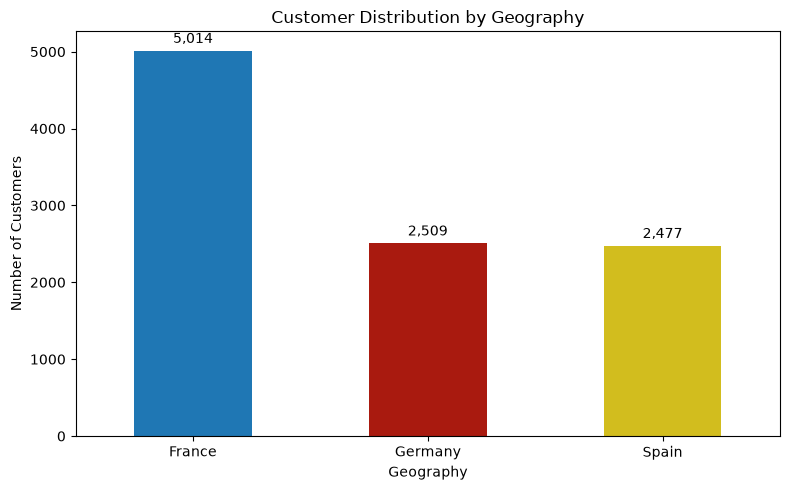

In [26]:
# Visualise customer distribution by geography

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

ax = geography_distribution.plot(kind="bar", color=["#1f77b4", "#a91a0f", "#d2bd1e"])

plt.title("Customer Distribution by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

for i, value in enumerate(geography_distribution):
    ax.text(i, value + 100, f"{value:,}", ha="center")
plt.tight_layout()

plt.savefig("../outputs/customer_distribution_by_geography.png", dpi=300, bbox_inches="tight")

plt.show()

### 3.2 Age Segmentation

Customers are grouped into four age segments to examine the demographic composition of the banking customer base. The defined age groups are Under 30, 30–45, 46–60, and 60+. The distribution of customers across these groups is examined before analysing differences in churn behaviour.

In [27]:
# Examine the age segment distribution

age_distribution = df_clean["AgeSegment"].value_counts().sort_index()

print("Customer distribution by age segment:")
print(age_distribution)

Customer distribution by age segment:
AgeSegment
Under 30    1641
30-45       6248
46-60       1647
60+          464
Name: count, dtype: int64


In [28]:
# Calculate the percentage distribution by age segment

age_percentage = (
    df_clean["AgeSegment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Percentage distribution by age segment:")
print(age_percentage)

Percentage distribution by age segment:
AgeSegment
30-45       62.48
46-60       16.47
Under 30    16.41
60+          4.64
Name: proportion, dtype: float64


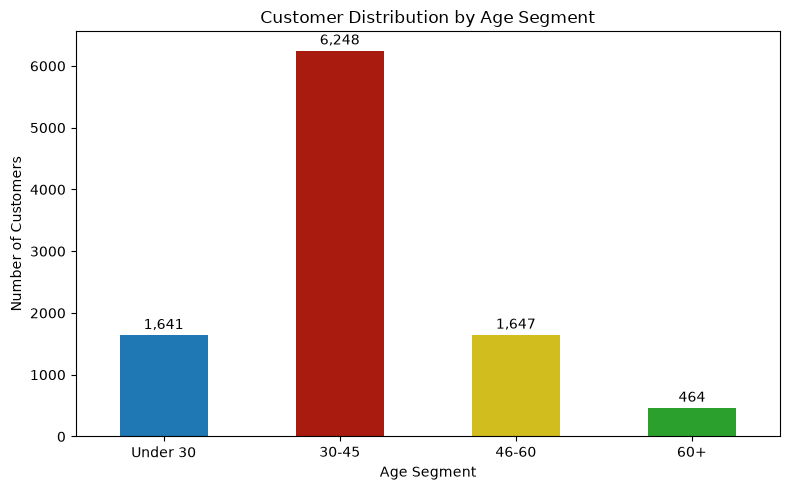

In [30]:
# Visualise customer distribution by age segment 

plt.figure(figsize=(8, 5))

ax = age_distribution.plot(kind="bar", color=["#1f77b4", "#a91a0f", "#d2bd1e", "#2ca02c"])

plt.title("Customer Distribution by Age Segment")
plt.xlabel("Age Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add customer counts above each bar
for i, value in enumerate(age_distribution):
    ax.text(i, value + 100, f"{value:,}", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/customer_distribution_by_age_segment.png", dpi=300, bbox_inches="tight"
)

plt.show()


### 3.3 Credit Score Segmentation

Customers are grouped into three credit score segments to examine the financial profile of the customer base. Credit scores below 580 are classified as Low, scores from 580 to 669 as Medium, and scores of 670 or above as High. The distribution of cutomers across these categories is examined before analysisng their relationship with churn. 

In [31]:
# Examine the credit score segment distribution

credit_score_distribution = (
    df_clean["CreditScoreSegment"]
    .value_counts()
    .sort_index()
)

print("Customer distribution by credit score segment:")
print(credit_score_distribution)

Customer distribution by credit score segment:
CreditScoreSegment
Low       2362
Medium    3331
High      4307
Name: count, dtype: int64


In [32]:
# Calculate the percentage distribution by credit score segment 

credit_score_percentage = (
    df_clean["CreditScoreSegment"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Percentage distribution by credit score segment:")
print(credit_score_percentage)

Percentage distribution by credit score segment:
CreditScoreSegment
Low       23.62
Medium    33.31
High      43.07
Name: proportion, dtype: float64


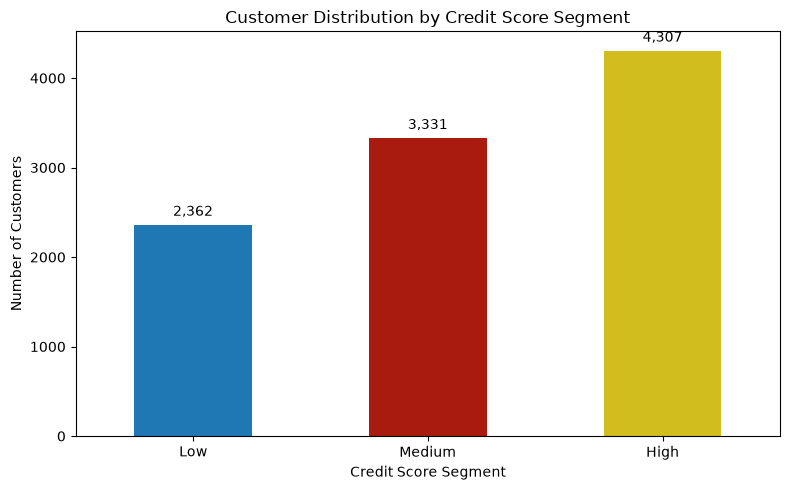

In [33]:
# Visualize customer distribution by credit score segment

plt.figure(figsize=(8, 5))

ax = credit_score_distribution.plot(kind="bar", color=["#1f77b4", "#a91a0f", "#d2bd1e"])

plt.title("Customer Distribution by Credit Score Segment")
plt.xlabel("Credit Score Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add customer counts above each bar
for i, value in enumerate(credit_score_distribution):
    ax.text(i, value + 100, f"{value:,}", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/customer_distribution_by_credit_score_segment.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 3.4 Tenure Segmentation

Customers are grouped according to their tenure with the bank to wxamine the composition of the customer base by length of relationship. Customers with a tenure of 0-3 years are classified as New, 4-7 years as Mid-term, and 8-10 years as Long-term. The distribution of these groups is examined before assessing differences in churn behaviour. 

In [34]:
# Examine the tenure segment distribution

tenure_distribution = (
    df_clean["TenureSegment"]
    .value_counts()
    .sort_index()
)

print("Customer distribution by tenure segment:")
print(tenure_distribution)

Customer distribution by tenure segment:
TenureSegment
New          3505
Mid-term     3996
Long-term    2499
Name: count, dtype: int64


In [35]:
# Calculate the percentage distribution by tenure segment

tenure_percentage = (
    df_clean["TenureSegment"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Percentage distribution by tenure segment:")
print(tenure_percentage)

Percentage distribution by tenure segment:
TenureSegment
New          35.05
Mid-term     39.96
Long-term    24.99
Name: proportion, dtype: float64


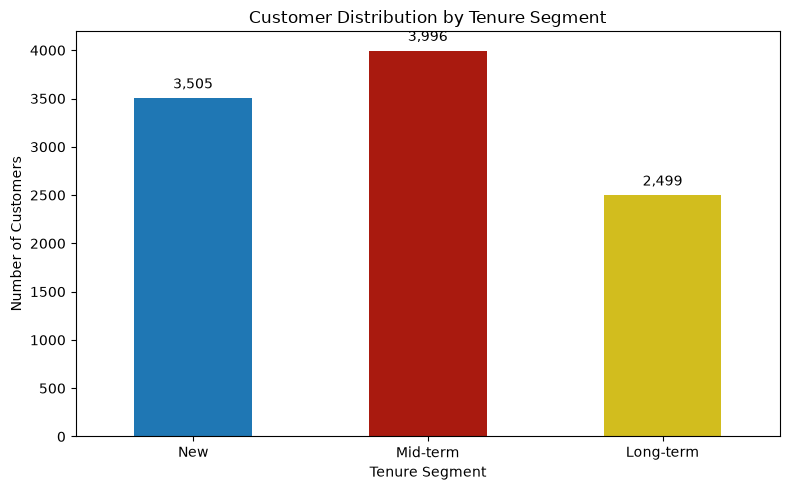

In [37]:
# Visualise customer distribution by tenure segment

plt.figure(figsize=(8, 5))

ax = tenure_distribution.plot(kind="bar", color=["#1f77b4", "#a91a0f", "#d2bd1e"])

plt.title("Customer Distribution by Tenure Segment")
plt.xlabel("Tenure Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add customer counts above each bar
for i, value in enumerate(tenure_distribution):
    ax.text(i, value + 100, f"{value:,}", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/customer_distribution_by_tenure_segment.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 3.5 Balance Segmentation

Customers are grouped according to their account balance to examine the financial composition of the customer base. Customers with a balance of zero are classified as Zero Balance, balances greater than zero but below £100,000 are classified as Low Balance, and balances of £100,000 or above are classified as High Balance. This segmentation will also support the subsequent analysis of high-value customer churn.

In [38]:
# Examine the balance segment distribution

balance_distribution = (
    df_clean["BalanceSegment"]
    .value_counts()
    .sort_index()
)

print("Customer distribution by balance segment:")
print(balance_distribution)

Customer distribution by balance segment:
BalanceSegment
Zero Balance    3617
Low Balance     1584
High Balance    4799
Name: count, dtype: int64


In [39]:
# Calculate the percentage distribution by balance segment

balance_percentage = (
    df_clean["BalanceSegment"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Percentage distribution by balance segment:")
print(balance_percentage)

Percentage distribution by balance segment:
BalanceSegment
Zero Balance    36.17
Low Balance     15.84
High Balance    47.99
Name: proportion, dtype: float64


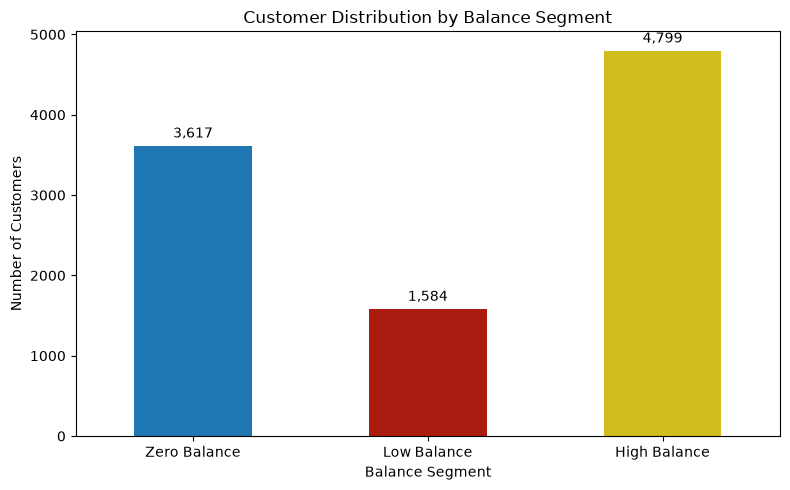

In [42]:
# Visualise customer distribution by balance segment

plt.figure(figsize=(8, 5))

ax = balance_distribution.plot(kind="bar", color=["#1f77b4", "#a91a0f", "#d2bd1e"])

plt.title("Customer Distribution by Balance Segment")
plt.xlabel("Balance Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add customer counts above each bar
for i, value in enumerate(balance_distribution):
    ax.text(i, value + 100, f"{value:,}", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/customer_distribution_by_balance_segment.png", dpi=300, bbox_inches="tight"
)

plt.show()

# 4. Churn Distribution Analysis

### 4.1 Overall Churn Rate

The overall churn rate represents the proportion of customers who have exited the bank relative to the total customer base. It provides a baseline measure of customer attrition against which churn rates across different customer segments can be compared.

In [43]:
# Calculate retained and churned customer counts

churn_counts = (
    df_clean["Exited"]
    .value_counts()
    .sort_index()
)

churn_counts.index = ["Retained", "Churned"]

print("Customer churn distribution:")
print(churn_counts)

Customer churn distribution:
Retained    7963
Churned     2037
Name: count, dtype: int64


In [44]:
# Calculate retained and churned customer percentages

churn_percentage = (
    df_clean["Exited"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

churn_percentage.index = ["Retained", "Churned"]

print("Customer churn percentage:")
print(churn_percentage)

Customer churn percentage:
Retained    79.63
Churned     20.37
Name: proportion, dtype: float64


In [45]:
# Calculate the overall churn rate

overall_churn_rate = df_clean["Exited"].mean() * 100

print(f"Overall churn rate: {overall_churn_rate:.2f}%")

Overall churn rate: 20.37%


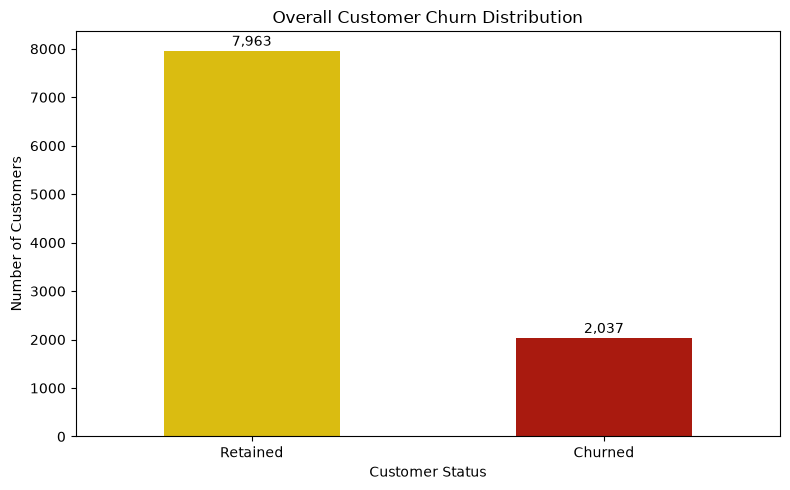

In [53]:
# Visualise retained versus churned customers

plt.figure(figsize=(8, 5))

ax = churn_counts.plot(kind="bar", color=["#dabc11", "#a91a0f"])

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

# Add customer counts above each bar
for i, value in enumerate(churn_counts):
    ax.text(i, value + 100, f"{value:,}", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/overall_customer_churn_distribution.png", dpi=300, bbox_inches="tight"
)

plt.show()

## 4.2 Segment-wise Churn Rates

The purpose is to compare each segment's churn rate against our overall baseline of 20.37%

### 4.2.1 Churn Rate by Geography

Churn rates are calculated for each geographic segment to identify differences in customer attrition across France, Germany, and Spain. The segment-level rates are compared with the overall churn rate of 20.37% to identify markets with relatively higher or lower customer churn.

In [54]:
# Calculate churn distribution by geography

geography_churn = (
    df_clean.groupby("Geography", observed=True)["Exited"]
    .agg(["count", "sum", "mean"])
)

geography_churn.columns = [
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

geography_churn["Churn Rate"] = (
    geography_churn["Churn Rate"] * 100
).round(2)

print("Churn analysis by geography:")
print(geography_churn)

Churn analysis by geography:
           Total Customers  Churned Customers  Churn Rate
Geography                                                
France                5014                810       16.15
Germany               2509                814       32.44
Spain                 2477                413       16.67


In [55]:
# Compare geographic churn rates with the overall churn rate

print(f"Overall churn rate: {overall_churn_rate:.2f}%")
print("\nChurn rate by geography:")
print(geography_churn["Churn Rate"])

Overall churn rate: 20.37%

Churn rate by geography:
Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Churn Rate, dtype: float64


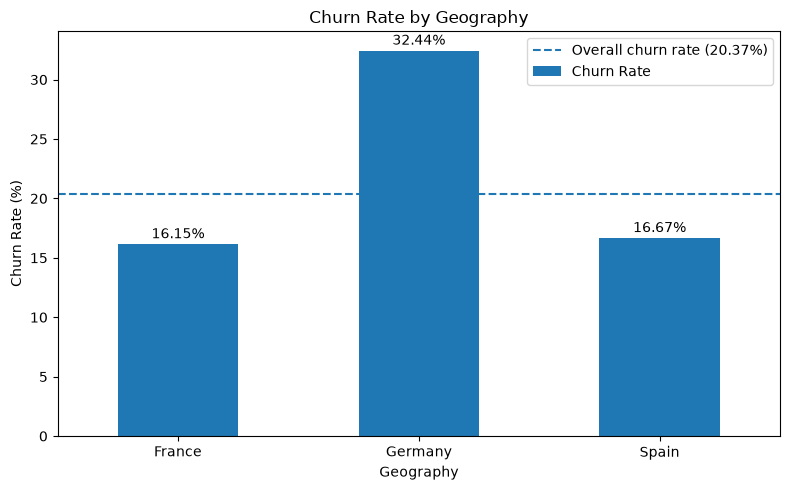

In [59]:
# Visualise churn rate by geography

plt.figure(figsize=(8, 5))

ax = geography_churn["Churn Rate"].plot(kind="bar")

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall churn rate ({overall_churn_rate:.2f}%)"
)

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend()

# Add churn rate labels
for i, value in enumerate(geography_churn["Churn Rate"]):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_rate_by_geography.png", dpi=300, bbox_inches="tight"
)
plt.show()

### 4.2.2 Churn Rate by Age Segment

Churn rates are calculated across the four age segments to identify differences in customer attrition by age. Each segment is compared with the overall churn rate of 20.37% to determine whether its churn level is above or below the customer base average.

In [60]:
# Calculate churn distribution by age segment

age_churn = (
    df_clean.groupby("AgeSegment", observed=True)["Exited"]
    .agg(["count", "sum", "mean"])
)

age_churn.columns = [
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

age_churn["Churn Rate"] = (
    age_churn["Churn Rate"] * 100
).round(2)

print("Churn analysis by age segment:")
print(age_churn)

Churn analysis by age segment:
            Total Customers  Churned Customers  Churn Rate
AgeSegment                                                
Under 30               1641                124        7.56
30-45                  6248                956       15.30
46-60                  1647                842       51.12
60+                     464                115       24.78


In [61]:
# Compare age-segment churn rates with the overall churn rate

print(f"Overall churn rate: {overall_churn_rate:.2f}%")
print("\nChurn rate by age segment:")
print(age_churn["Churn Rate"])

Overall churn rate: 20.37%

Churn rate by age segment:
AgeSegment
Under 30     7.56
30-45       15.30
46-60       51.12
60+         24.78
Name: Churn Rate, dtype: float64


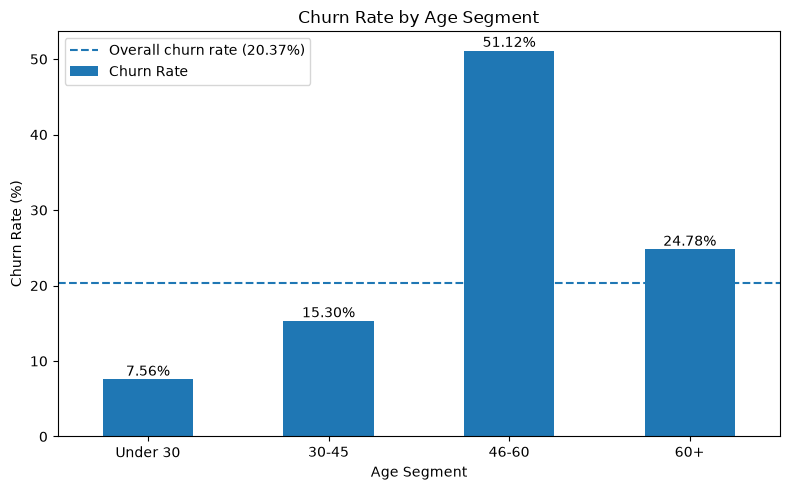

In [63]:
# Visualise churn rate by age segment

plt.figure(figsize=(8, 5))

ax = age_churn["Churn Rate"].plot(kind="bar", legend=False)

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall churn rate ({overall_churn_rate:.2f}%)"
)

plt.title("Churn Rate by Age Segment")
plt.xlabel("Age Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend()

# Add churn rate labels
for i, value in enumerate(age_churn["Churn Rate"]):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_rate_by_age_segment.png", dpi=300, bbox_inches="tight"
)
plt.show()

### 4.2.3 Churn Rate by Credit Score Segment

Churn rates are calculated across the three credit score segments to examine whether customer attrition differs according to credit profile. Each segment is compared with the overall churn rate of 20.37% to identify groups with relatively higher or lower churn.

In [64]:
# Calculate churn distribution by credit score segment

credit_score_churn = (
    df_clean.groupby("CreditScoreSegment", observed=True)["Exited"]
    .agg(["count", "sum", "mean"])
)

credit_score_churn.columns = [
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

credit_score_churn["Churn Rate"] = (
    credit_score_churn["Churn Rate"] * 100
).round(2)

print("Churn analysis by credit score segment:")
print(credit_score_churn)

Churn analysis by credit score segment:
                    Total Customers  Churned Customers  Churn Rate
CreditScoreSegment                                                
Low                            2362                520       22.02
Medium                         3331                685       20.56
High                           4307                832       19.32


In [65]:
# Compare credit score churn rates with the overall churn rate

print(f"Overall churn rate: {overall_churn_rate:.2f}%")
print("\nChurn rate by credit score segment:")
print(credit_score_churn["Churn Rate"])

Overall churn rate: 20.37%

Churn rate by credit score segment:
CreditScoreSegment
Low       22.02
Medium    20.56
High      19.32
Name: Churn Rate, dtype: float64


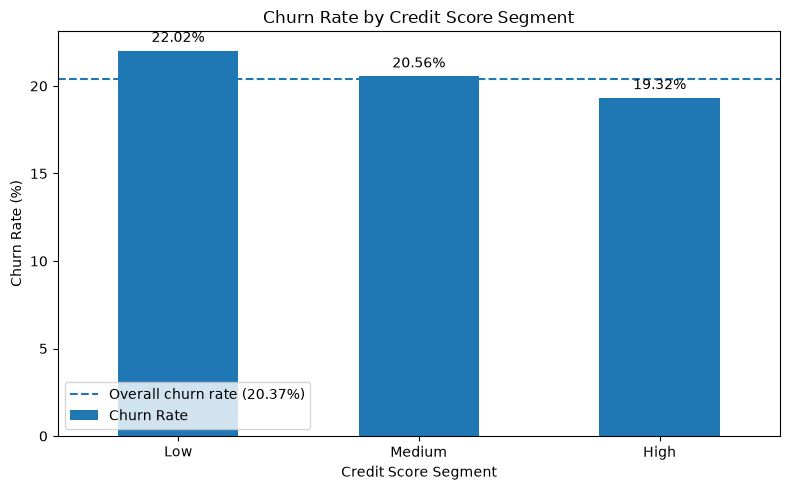

In [67]:
# Visualise churn rate by credit score segment

plt.figure(figsize=(8, 5))

ax = credit_score_churn["Churn Rate"].plot(kind="bar", legend=False)

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall churn rate ({overall_churn_rate:.2f}%)"
)

plt.title("Churn Rate by Credit Score Segment")
plt.xlabel("Credit Score Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend()

# Add churn rate labels
for i, value in enumerate(credit_score_churn["Churn Rate"]):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_rate_by_credit_score_segment.png", dpi=300, bbox_inches="tight"
)
plt.show()

### 4.2.4 Churn Rate by Tenure Segment

Churn rates are calculated across the three tenure segments to examine whether customer attrition varies according to the length of the customer relationship with the bank. Each segment is compared with the overall churn rate of 20.37% to identify groups with relatively higher or lower churn.

In [68]:
# Calculate churn distribution by tenure segment

tenure_churn = (
    df_clean.groupby("TenureSegment", observed=True)["Exited"]
    .agg(["count", "sum", "mean"])
)

tenure_churn.columns = [
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

tenure_churn["Churn Rate"] = (
    tenure_churn["Churn Rate"] * 100
).round(2)

print("Churn analysis by tenure segment:")
print(tenure_churn)

Churn analysis by tenure segment:
               Total Customers  Churned Customers  Churn Rate
TenureSegment                                                
New                       3505                741       21.14
Mid-term                  3996                785       19.64
Long-term                 2499                511       20.45


In [69]:
# Compare tenure churn rates with the overall churn rate

print(f"Overall churn rate: {overall_churn_rate:.2f}%")
print("\nChurn rate by tenure segment:")
print(tenure_churn["Churn Rate"])

Overall churn rate: 20.37%

Churn rate by tenure segment:
TenureSegment
New          21.14
Mid-term     19.64
Long-term    20.45
Name: Churn Rate, dtype: float64


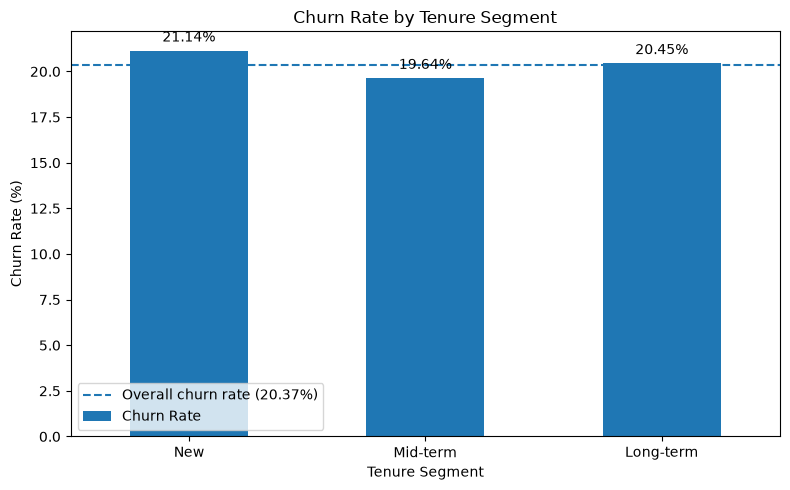

In [71]:
# Visualise churn rate by tenure segment

plt.figure(figsize=(8, 5))

ax = tenure_churn["Churn Rate"].plot(kind="bar", legend=False)

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall churn rate ({overall_churn_rate:.2f}%)"
)

plt.title("Churn Rate by Tenure Segment")
plt.xlabel("Tenure Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend()

# Add churn rate labels
for i, value in enumerate(tenure_churn["Churn Rate"]):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_rate_by_tenure_segment.png", dpi=300, bbox_inches="tight"
)
plt.show()

### 4.2.5 Churn Rate by Balance Segment

Churn rates are calculated across the three balance segments to examine whether customer attrition differs according to customers' account balances. The segments are compared with the overall churn rate of 20.37% to identify whether customers with different financial positions exhibit different levels of churn.

In [72]:
# Calculate churn distribution by balance segment

balance_churn = (
    df_clean.groupby("BalanceSegment", observed=True)["Exited"]
    .agg(["count", "sum", "mean"])
)

balance_churn.columns = [
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

balance_churn["Churn Rate"] = (
    balance_churn["Churn Rate"] * 100
).round(2)

print("Churn analysis by balance segment:")
print(balance_churn)

Churn analysis by balance segment:
                Total Customers  Churned Customers  Churn Rate
BalanceSegment                                                
Zero Balance               3617                500       13.82
Low Balance                1584                326       20.58
High Balance               4799               1211       25.23


In [73]:
# Compare balance churn rates with the overall churn rate

print(f"Overall churn rate: {overall_churn_rate:.2f}%")
print("\nChurn rate by balance segment:")
print(balance_churn["Churn Rate"])

Overall churn rate: 20.37%

Churn rate by balance segment:
BalanceSegment
Zero Balance    13.82
Low Balance     20.58
High Balance    25.23
Name: Churn Rate, dtype: float64


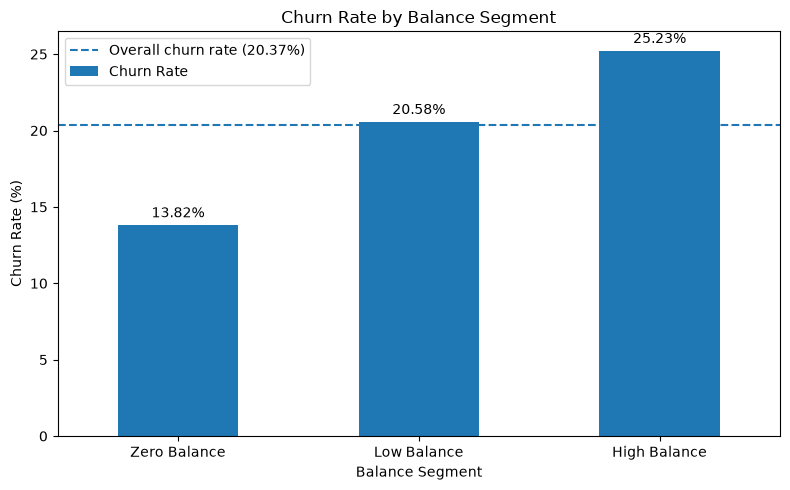

In [75]:
# Visualise churn rate by balance segment

plt.figure(figsize=(8, 5))

ax = balance_churn["Churn Rate"].plot(kind="bar")

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall churn rate ({overall_churn_rate:.2f}%)"
)

plt.title("Churn Rate by Balance Segment")
plt.xlabel("Balance Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend()

# Add churn rate labels
for i, value in enumerate(balance_churn["Churn Rate"]):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_rate_by_balance_segment.png", dpi=300, bbox_inches="tight"
)

plt.show()

# 4.3 Churn Contribution by Segment Size

### 4.3.1 Churn Contribution by Geography

Churn contribution measures the proportion of all churned customers originating from each geographic segment. Unlike churn rate, which accounts for the size of each segment, churn contribution reflects the absolute distribution of churned customers across the customer base. This distinction helps identify segments that contribute substantially to the total number of churned customers.

In [76]:
# Calculate churn contribution by geography

geography_contribution = (
    df_clean[df_clean["Exited"] == 1]
    ["Geography"]
    .value_counts()
    .sort_index()
)

geography_contribution_percentage = (
    geography_contribution
    .div(geography_contribution.sum())
    .mul(100)
    .round(2)
)

print("Churned customers by geography:")
print(geography_contribution)

print("\nChurn contribution by geography:")
print(geography_contribution_percentage)

Churned customers by geography:
Geography
France     810
Germany    814
Spain      413
Name: count, dtype: int64

Churn contribution by geography:
Geography
France     39.76
Germany    39.96
Spain      20.27
Name: count, dtype: float64


In [77]:
# Verify that all churned customers are included

print(
    f"Total churned customers: "
    f"{geography_contribution.sum():,}"
)

print(
    f"Total contribution: "
    f"{geography_contribution_percentage.sum():.2f}%"
)

Total churned customers: 2,037
Total contribution: 99.99%


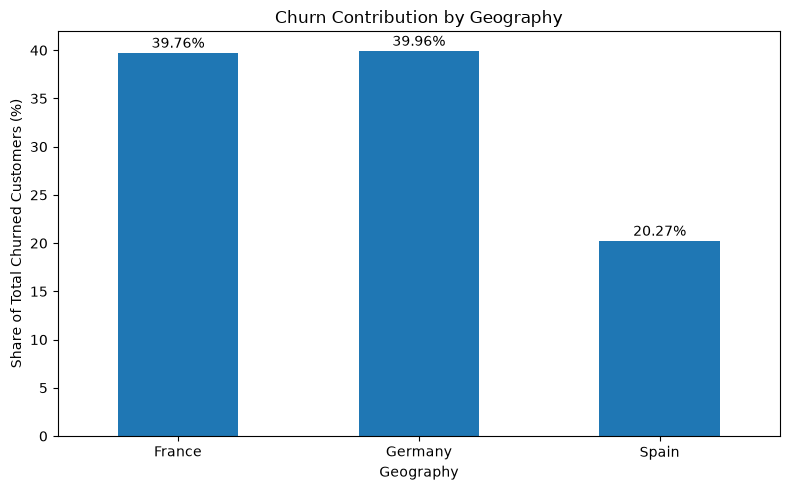

In [79]:
# Visualise churn contribution by geography

plt.figure(figsize=(8, 5))

ax = geography_contribution_percentage.plot(kind="bar")

plt.title("Churn Contribution by Geography")
plt.xlabel("Geography")
plt.ylabel("Share of Total Churned Customers (%)")
plt.xticks(rotation=0)

# Add contribution percentages above each bar
for i, value in enumerate(geography_contribution_percentage):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_contribution_by_geography.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 4.3.2 Churn Contribution by Age Segment

Churn contribution is calculated for each age segment to determine the proportion of all churned customers originating from each group. This complements the segment-level churn rate by considering the number of customers within each age segment and its contribution to the overall population of churned customers.

In [80]:
# Calculate churn contribution by age segment

age_contribution = (
    df_clean[df_clean["Exited"] == 1]
    ["AgeSegment"]
    .value_counts()
    .sort_index()
)

age_contribution_percentage = (
    age_contribution
    .div(age_contribution.sum())
    .mul(100)
    .round(2)
)

print("Churned customers by age segment:")
print(age_contribution)

print("\nChurn contribution by age segment:")
print(age_contribution_percentage)

Churned customers by age segment:
AgeSegment
Under 30    124
30-45       956
46-60       842
60+         115
Name: count, dtype: int64

Churn contribution by age segment:
AgeSegment
Under 30     6.09
30-45       46.93
46-60       41.34
60+          5.65
Name: count, dtype: float64


In [81]:
# Verify that all churned customers are included

print(
    f"Total churned customers: "
    f"{age_contribution.sum():,}"
)

print(
    f"Total contribution: "
    f"{age_contribution_percentage.sum():.2f}%"
)

Total churned customers: 2,037
Total contribution: 100.01%


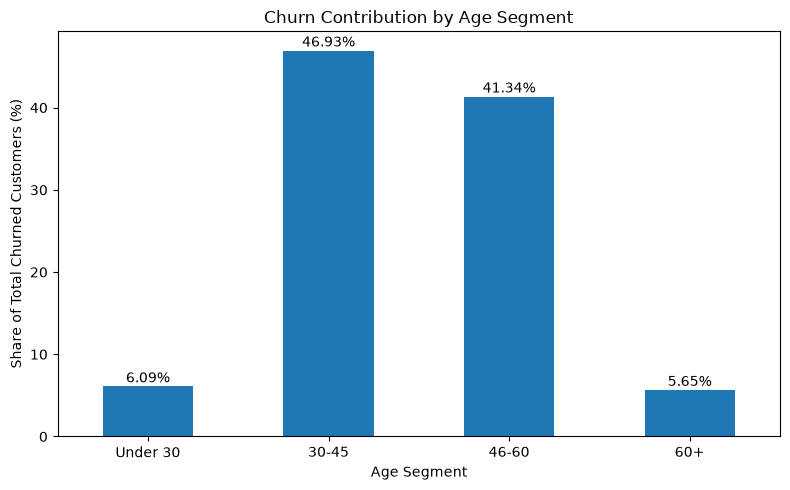

In [83]:
# Visualise churn contribution by age segment

plt.figure(figsize=(8, 5))

ax = age_contribution_percentage.plot(kind="bar")

plt.title("Churn Contribution by Age Segment")
plt.xlabel("Age Segment")
plt.ylabel("Share of Total Churned Customers (%)")
plt.xticks(rotation=0)

# Add contribution percentages above each bar
for i, value in enumerate(age_contribution_percentage):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_contribution_by_age_segment.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 4.3.3 Churn Contribution by Credit Score Segment

Churn contribution is calculated for each credit score segment to determine the proportion of all churned customers originating from each group. This analysis complements the segment-level churn rate by showing how each credit score group contributes to the total number of churned customers.

In [84]:
# Calculate churn contribution by credit score segment

credit_score_contribution = (
    df_clean[df_clean["Exited"] == 1]
    ["CreditScoreSegment"]
    .value_counts()
    .sort_index()
)

credit_score_contribution_percentage = (
    credit_score_contribution
    .div(credit_score_contribution.sum())
    .mul(100)
    .round(2)
)

print("Churned customers by credit score segment:")
print(credit_score_contribution)

print("\nChurn contribution by credit score segment:")
print(credit_score_contribution_percentage)

Churned customers by credit score segment:
CreditScoreSegment
Low       520
Medium    685
High      832
Name: count, dtype: int64

Churn contribution by credit score segment:
CreditScoreSegment
Low       25.53
Medium    33.63
High      40.84
Name: count, dtype: float64


In [85]:
# Verify that all churned customers are included

print(
    f"Total churned customers: "
    f"{credit_score_contribution.sum():,}"
)

print(
    f"Total contribution: "
    f"{credit_score_contribution_percentage.sum():.2f}%"
)

Total churned customers: 2,037
Total contribution: 100.00%


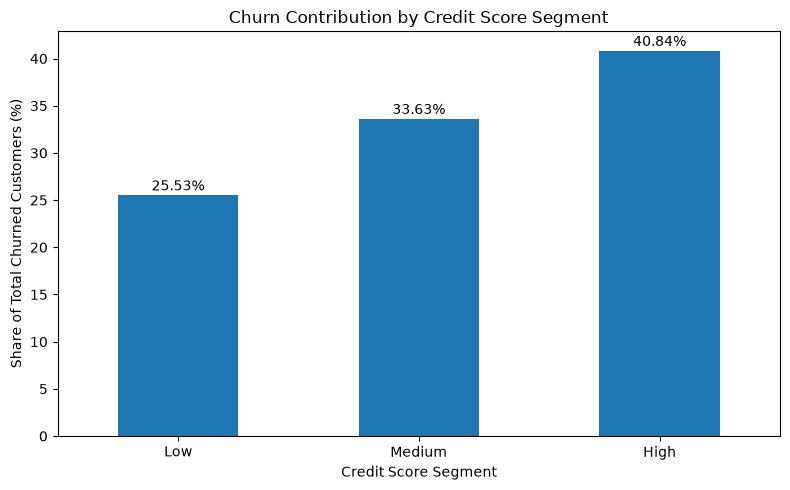

In [87]:
# Visualise churn contribution by credit score segment

plt.figure(figsize=(8, 5))

ax = credit_score_contribution_percentage.plot(kind="bar")

plt.title("Churn Contribution by Credit Score Segment")
plt.xlabel("Credit Score Segment")
plt.ylabel("Share of Total Churned Customers (%)")
plt.xticks(rotation=0)

# Add contribution percentages above each bar
for i, value in enumerate(credit_score_contribution_percentage):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_contribution_by_credit_score_segment.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 4.3.4 Churn Contribution by Tenure Segment

Churn contribution is calculated for each tenure segment to determine the proportion of all churned customers originating from New, Mid-term, and Long-term customers. This analysis complements the tenure-specific churn rates by considering the contribution of each segment to the total churn population.

In [88]:
# Calculate churn contribution by tenure segment

tenure_contribution = (
    df_clean[df_clean["Exited"] == 1]
    ["TenureSegment"]
    .value_counts()
    .sort_index()
)

tenure_contribution_percentage = (
    tenure_contribution
    .div(tenure_contribution.sum())
    .mul(100)
    .round(2)
)

print("Churned customers by tenure segment:")
print(tenure_contribution)

print("\nChurn contribution by tenure segment:")
print(tenure_contribution_percentage)

Churned customers by tenure segment:
TenureSegment
New          741
Mid-term     785
Long-term    511
Name: count, dtype: int64

Churn contribution by tenure segment:
TenureSegment
New          36.38
Mid-term     38.54
Long-term    25.09
Name: count, dtype: float64


In [89]:
# Verify that all churned customers are included

print(
    f"Total churned customers: "
    f"{tenure_contribution.sum():,}"
)

print(
    f"Total contribution: "
    f"{tenure_contribution_percentage.sum():.2f}%"
)

Total churned customers: 2,037
Total contribution: 100.01%


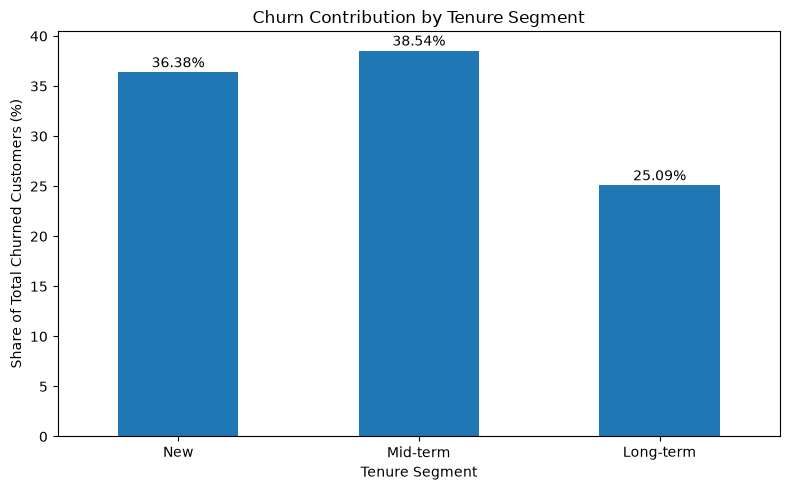

In [93]:
# Visualise churn contribution by tenure segment

plt.figure(figsize=(8, 5))

ax = tenure_contribution_percentage.plot(kind="bar")

plt.title("Churn Contribution by Tenure Segment")
plt.xlabel("Tenure Segment")
plt.ylabel("Share of Total Churned Customers (%)")
plt.xticks(rotation=0)

# Add contribution percentages above each bar
for i, value in enumerate(tenure_contribution_percentage):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_contribution_by_tenure_segment.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 4.3.5 Churn Contribution by Balance Segment

Churn contribution is calculated for each balance segment to determine the proportion of all churned customers originating from customers with Zero Balance, Low Balance, and High Balance. This analysis complements the balance-specific churn rates by showing the contribution of each financial segment to the overall churn population.

In [94]:
# Calculate churn contribution by balance segment

balance_contribution = (
    df_clean[df_clean["Exited"] == 1]
    ["BalanceSegment"]
    .value_counts()
    .sort_index()
)

balance_contribution_percentage = (
    balance_contribution
    .div(balance_contribution.sum())
    .mul(100)
    .round(2)
)

print("Churned customers by balance segment:")
print(balance_contribution)

print("\nChurn contribution by balance segment:")
print(balance_contribution_percentage)

Churned customers by balance segment:
BalanceSegment
Zero Balance     500
Low Balance      326
High Balance    1211
Name: count, dtype: int64

Churn contribution by balance segment:
BalanceSegment
Zero Balance    24.55
Low Balance     16.00
High Balance    59.45
Name: count, dtype: float64


In [95]:
# Verify that all churned customers are included

print(
    f"Total churned customers: "
    f"{balance_contribution.sum():,}"
)

print(
    f"Total contribution: "
    f"{balance_contribution_percentage.sum():.2f}%"
)

Total churned customers: 2,037
Total contribution: 100.00%


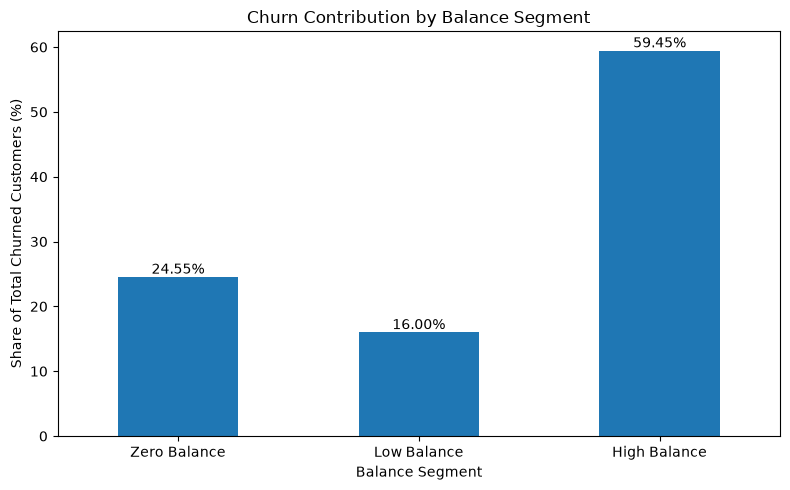

In [97]:
# Visualise churn contribution by balance segment

plt.figure(figsize=(8, 5))

ax = balance_contribution_percentage.plot(kind="bar")

plt.title("Churn Contribution by Balance Segment")
plt.xlabel("Balance Segment")
plt.ylabel("Share of Total Churned Customers (%)")
plt.xticks(rotation=0)

# Add contribution percentages above each bar
for i, value in enumerate(balance_contribution_percentage):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_contribution_by_balance_segment.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 4.4 Churned vs Retained Profiles

So far, we've analysed where churn occurs across our defined segments. Now we want to understand whether the overall characteristics of churned customers differ from retained customers.

We'll approach this systematically rather than putting everything into one large table.

First, we'll compare the numerical customer characteristics between the two groups:

- Credit Score
- Age
- Tenure
- Balance
- Number of Products
- Estimated Salary

This will give us a clear profile of the typical churned versus retained customer.

### 4.4.1 Numerical Profile: Churned vs Retained

The numerical characteristics of churned and retained customers are compared to identify differences in their financial, demographic, and relationship profiles. Mean values are examined across the two customer groups for Credit Score, Age, Tenure, Balance, Number of Products, and Estimated Salary.

In [98]:
# Compare numerical customer characteristics between retained and churned customers

numeric_profile = (
    df_clean.groupby("Exited")[[
        "CreditScore",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts",
        "EstimatedSalary"
    ]]
    .mean()
    .round(2)
)

numeric_profile.index = ["Retained", "Churned"]

print("Numerical profile of retained and churned customers:")
print(numeric_profile)

Numerical profile of retained and churned customers:
          CreditScore    Age  Tenure   Balance  NumOfProducts  EstimatedSalary
Retained       651.85  37.41    5.03  72745.30           1.54         99738.39
Churned        645.35  44.84    4.93  91108.54           1.48        101465.68


In [99]:
# Compare median values between retained and churned customers
# Why are we using both mean and median?
# For example, a few customers with exceptionally high balances could influence the mean balance.
# The median tells us what the middle customer looks like and gives us a useful robustness check.

numeric_profile_median = (
    df_clean.groupby("Exited")[[
        "CreditScore",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts",
        "EstimatedSalary"
    ]]
    .median()
    .round(2)
)

numeric_profile_median.index = ["Retained", "Churned"]

print("Median numerical profile of retained and churned customers:")
print(numeric_profile_median)

Median numerical profile of retained and churned customers:
          CreditScore   Age  Tenure    Balance  NumOfProducts  EstimatedSalary
Retained        653.0  36.0     5.0   92072.68            2.0         99645.04
Churned         646.0  45.0     5.0  109349.29            1.0        102460.84


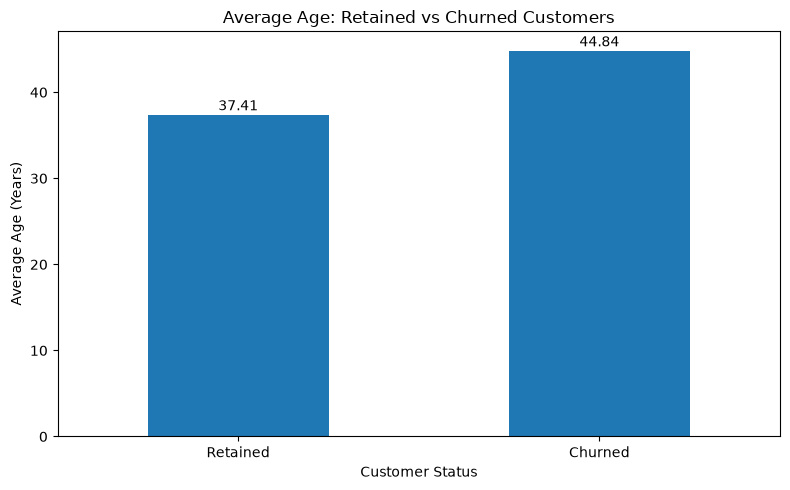

In [104]:
# Compare average age between retained and churned customers

age_profile = df_clean.groupby("Exited")["Age"].mean()

age_profile.index = ["Retained", "Churned"]

plt.figure(figsize=(8, 5))

ax = age_profile.plot(kind="bar")

plt.title("Average Age: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Average Age (Years)")
plt.xticks(rotation=0)

for i, value in enumerate(age_profile):
    ax.text(i, value + 0.5, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/average_age_retained_vs_churned.png", dpi=300, bbox_inches="tight"
)

plt.show()

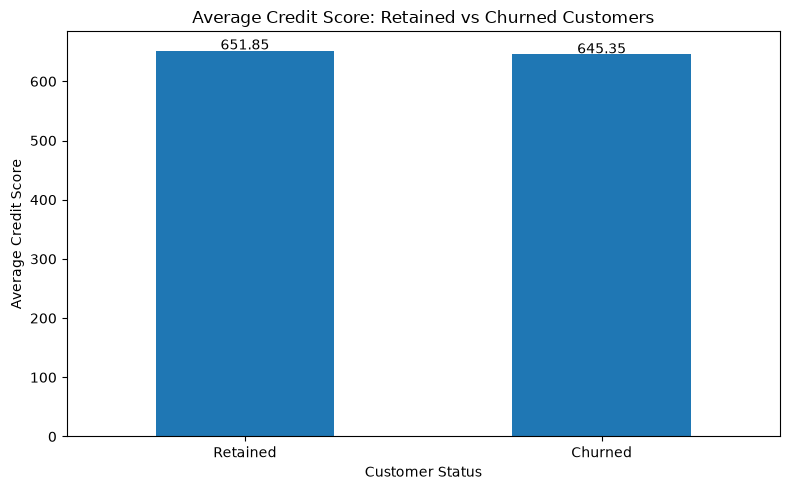

In [106]:
# Compare average credit score between retained and churned customers

credit_score_profile = df_clean.groupby("Exited")["CreditScore"].mean()

credit_score_profile.index = ["Retained", "Churned"]

plt.figure(figsize=(8, 5))

ax = credit_score_profile.plot(kind="bar")

plt.title("Average Credit Score: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Average Credit Score")
plt.xticks(rotation=0)

for i, value in enumerate(credit_score_profile):
    ax.text(i, value + 2, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/average_credit_score_retained_vs_churned.png", dpi=300, bbox_inches="tight"
)

plt.show()

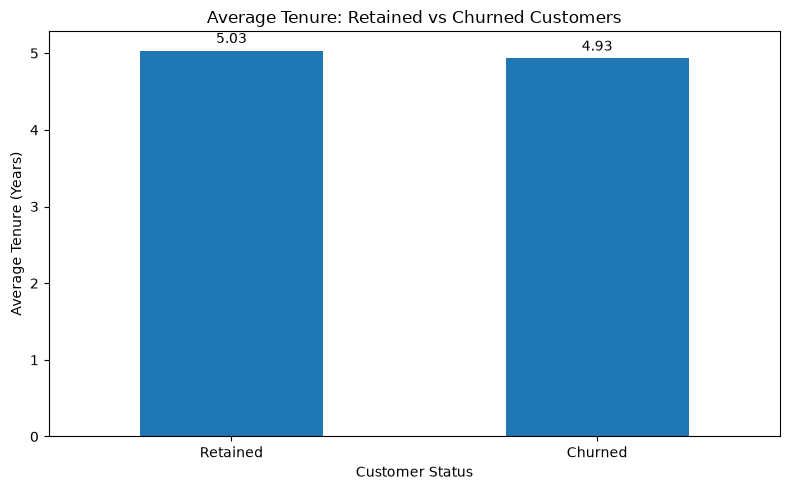

In [108]:
# Compare average tenure between retained and churned customers

tenure_profile = df_clean.groupby("Exited")["Tenure"].mean()

tenure_profile.index = ["Retained", "Churned"]

plt.figure(figsize=(8, 5))

ax = tenure_profile.plot(kind="bar")

plt.title("Average Tenure: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Average Tenure (Years)")
plt.xticks(rotation=0)

for i, value in enumerate(tenure_profile):
    ax.text(i, value + 0.1, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.savefig("../outputs/average_tenure_retained_vs_churned.png", dpi=300, bbox_inches="tight")

plt.show()

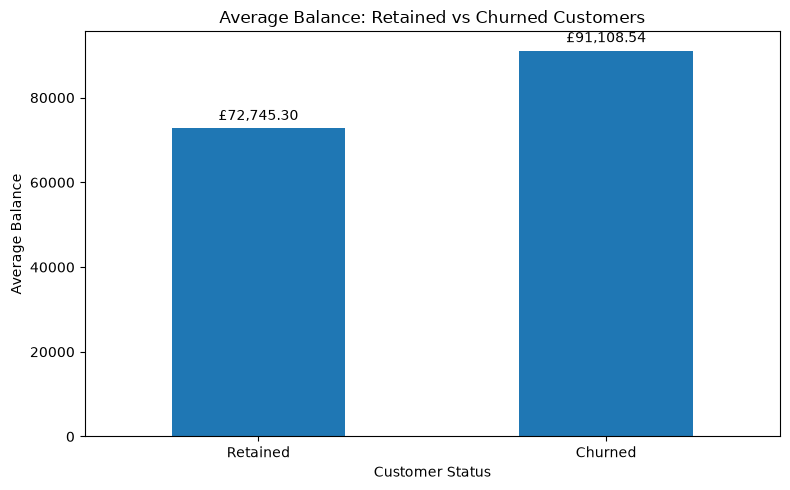

In [110]:
# Compare average balance between retained and churned customers

balance_profile = df_clean.groupby("Exited")["Balance"].mean()

balance_profile.index = ["Retained", "Churned"]

plt.figure(figsize=(8, 5))

ax = balance_profile.plot(kind="bar")

plt.title("Average Balance: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Average Balance")
plt.xticks(rotation=0)

for i, value in enumerate(balance_profile):
    ax.text(i, value + 2000, f"£{value:,.2f}", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/average_balance_retained_vs_churned.png", dpi=300, bbox_inches="tight"
)

plt.show()

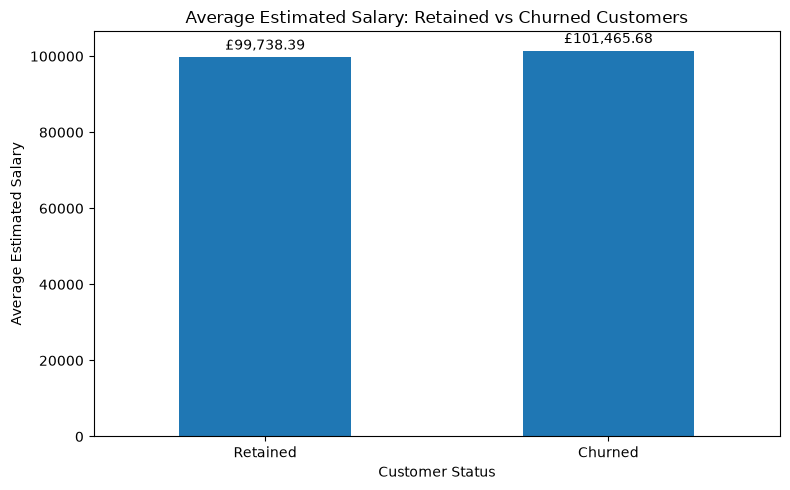

In [112]:
# Compare average estimated salary between retained and churned customers

salary_profile = df_clean.groupby("Exited")["EstimatedSalary"].mean()

salary_profile.index = ["Retained", "Churned"]

plt.figure(figsize=(8, 5))

ax = salary_profile.plot(kind="bar")

plt.title("Average Estimated Salary: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Average Estimated Salary")
plt.xticks(rotation=0)

for i, value in enumerate(salary_profile):
    ax.text(i, value + 2000, f"£{value:,.2f}", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/average_salary_retained_vs_churned.png", dpi=300, bbox_inches="tight"
)

plt.show()

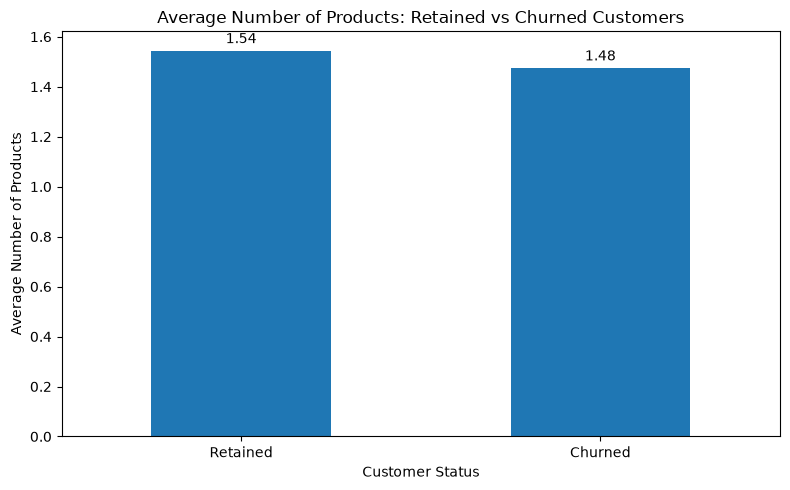

In [114]:
# Compare average number of products between retained and churned customers

products_profile = df_clean.groupby("Exited")["NumOfProducts"].mean()

products_profile.index = ["Retained", "Churned"]

plt.figure(figsize=(8, 5))

ax = products_profile.plot(kind="bar")

plt.title("Average Number of Products: Retained vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Average Number of Products")
plt.xticks(rotation=0)

for i, value in enumerate(products_profile):
    ax.text(i, value + 0.03, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/average_products_retained_vs_churned.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 4.4.2 Categorical Profile: Churned vs Retained

- Geography
- Gender
- HasCrCard
- IsActiveMember

For these variables, comparing percentages within each customer-status group is more meaningful than simply comparing counts.

The geographic composition of retained and churned customers is compared to identify differences in customer distribution across France, Germany, and Spain. Percentages are calculated within each customer-status group to account for differences in group size.

In [115]:
# Compare geographic composition of retained and churned customers

geography_profile = pd.crosstab(
    df_clean["Geography"],
    df_clean["Exited"],
    normalize="columns"
).mul(100).round(2)

geography_profile.columns = ["Retained", "Churned"]

print("Geographic profile of retained and churned customers:")
print(geography_profile)

Geographic profile of retained and churned customers:
           Retained  Churned
Geography                   
France        52.79    39.76
Germany       21.29    39.96
Spain         25.92    20.27


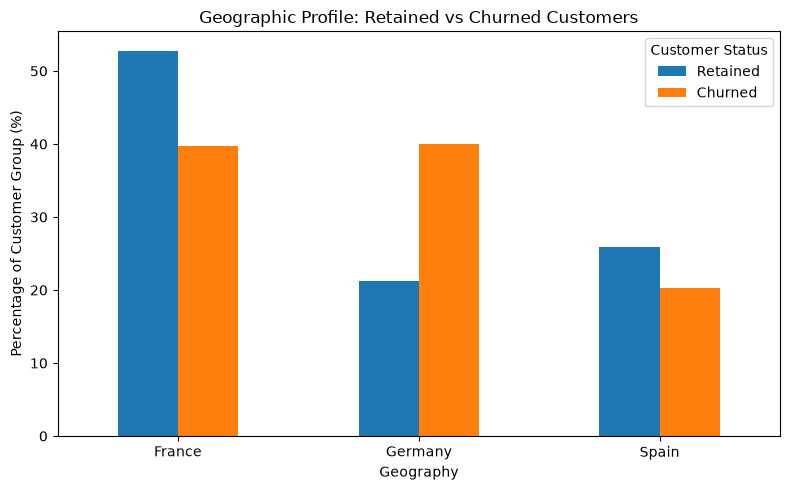

In [117]:
# Visualise geographic composition of retained and churned customers

geography_profile.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Geographic Profile: Retained vs Churned Customers")
plt.xlabel("Geography")
plt.ylabel("Percentage of Customer Group (%)")
plt.xticks(rotation=0)
plt.legend(title="Customer Status")

plt.tight_layout()
plt.savefig(
    "../outputs/geographic_profile_retained_vs_churned.png", dpi=300, bbox_inches="tight"
)

plt.show()

In [118]:
# Compare gender composition of retained and churned customers

gender_profile = pd.crosstab(
    df_clean["Gender"],
    df_clean["Exited"],
    normalize="columns"
).mul(100).round(2)

gender_profile.columns = ["Retained", "Churned"]

print("Gender profile of retained and churned customers:")
print(gender_profile)

Gender profile of retained and churned customers:
        Retained  Churned
Gender                   
Female     42.75    55.92
Male       57.25    44.08


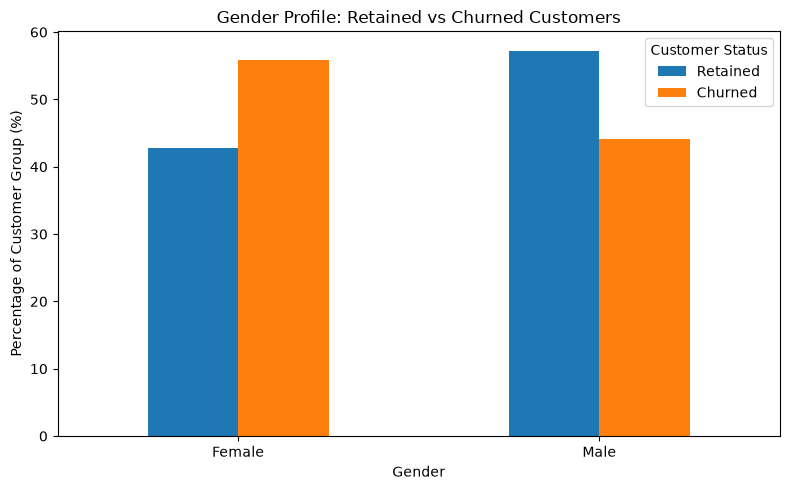

In [121]:
# Visualise gender composition of retained and churned customers

gender_profile.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Gender Profile: Retained vs Churned Customers")
plt.xlabel("Gender")
plt.ylabel("Percentage of Customer Group (%)")
plt.xticks(rotation=0)
plt.legend(title="Customer Status")

plt.tight_layout()
plt.savefig(
    "../outputs/gender_profile_retained_vs_churned.png", dpi=300, bbox_inches="tight"
)

plt.show()

In [122]:
# Compare credit card ownership between retained and churned customers

credit_card_profile = pd.crosstab(
    df_clean["HasCrCard"],
    df_clean["Exited"],
    normalize="columns"
).mul(100).round(2)

credit_card_profile.index = ["No Credit Card", "Has Credit Card"]
credit_card_profile.columns = ["Retained", "Churned"]

print("Credit card profile of retained and churned customers:")
print(credit_card_profile)

Credit card profile of retained and churned customers:
                 Retained  Churned
No Credit Card      29.29    30.09
Has Credit Card     70.71    69.91


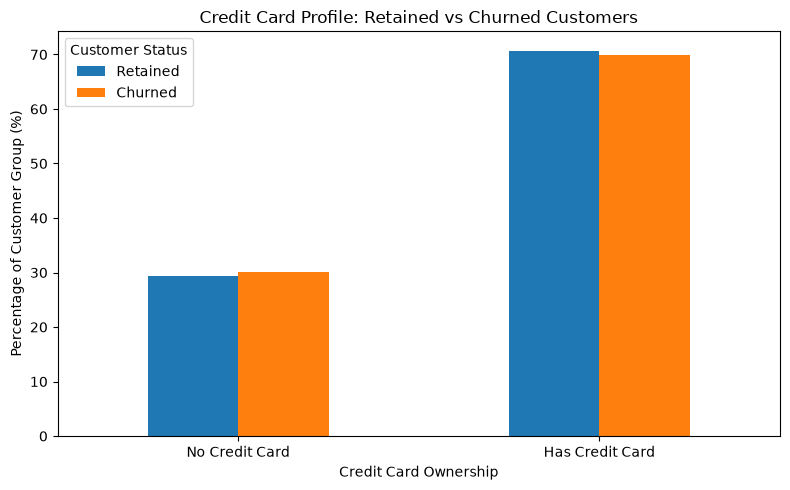

In [124]:
# Visualise credit card ownership of retained and churned customers

credit_card_profile.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Credit Card Profile: Retained vs Churned Customers")
plt.xlabel("Credit Card Ownership")
plt.ylabel("Percentage of Customer Group (%)")
plt.xticks(rotation=0)
plt.legend(title="Customer Status")

plt.tight_layout()
plt.savefig(
    "../outputs/credit_card_profile_retained_vs_churned.png", dpi=300, bbox_inches="tight"
)

plt.show()

In [125]:
# Compare active membership between retained and churned customers

active_member_profile = pd.crosstab(
    df_clean["IsActiveMember"],
    df_clean["Exited"],
    normalize="columns"
).mul(100).round(2)

active_member_profile.index = ["Inactive Member", "Active Member"]
active_member_profile.columns = ["Retained", "Churned"]

print("Active member profile of retained and churned customers:")
print(active_member_profile)

Active member profile of retained and churned customers:
                 Retained  Churned
Inactive Member     44.54    63.92
Active Member       55.46    36.08


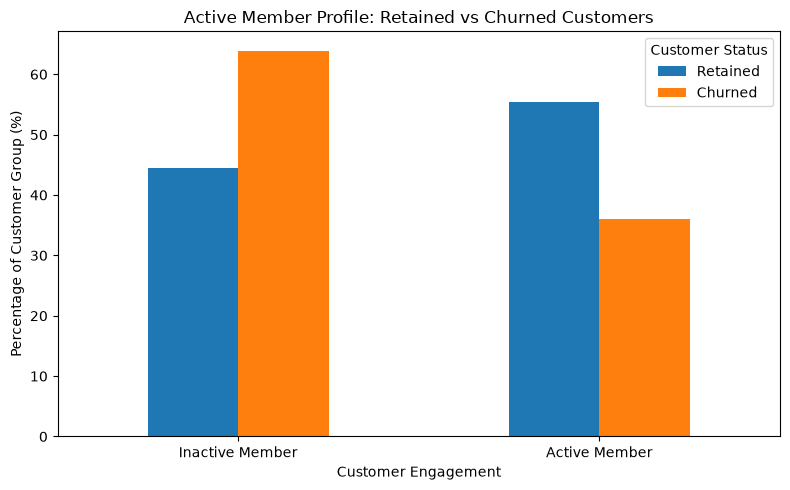

In [126]:
# Visualise active membership of retained and churned customers

active_member_profile.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Active Member Profile: Retained vs Churned Customers")
plt.xlabel("Customer Engagement")
plt.ylabel("Percentage of Customer Group (%)")
plt.xticks(rotation=0)
plt.legend(title="Customer Status")

plt.tight_layout()
plt.savefig(
    "../outputs/active_member_profile_retianed_vs_churned.png"
)

plt.show()

# 5. Comparative Demographic Analysis

### 5.1 Gender-based Churn

Gender-specific churn rates are calculated to compare customer attrition between female and male customers. The analysis considers the proportion of customers within each gender who have churned, rather than comparing the absolute number of churned customers. The gender-specific rates are also compared with the overall churn rate of 20.37%.

In [127]:
# Calculate churn rate by gender

gender_churn = (
    df_clean.groupby("Gender", observed=True)["Exited"]
    .agg(["count", "sum", "mean"])
)

gender_churn.columns = [
    "Total Customers",
    "Churned Customers",
    "Churn Rate"
]

gender_churn["Churn Rate"] = (
    gender_churn["Churn Rate"] * 100
).round(2)

print("Churn analysis by gender:")
print(gender_churn)

Churn analysis by gender:
        Total Customers  Churned Customers  Churn Rate
Gender                                                
Female             4543               1139       25.07
Male               5457                898       16.46


In [128]:
# Compare gender-specific churn rates with the overall churn rate

print(f"Overall churn rate: {overall_churn_rate:.2f}%")
print("\nChurn rate by gender:")
print(gender_churn["Churn Rate"])

Overall churn rate: 20.37%

Churn rate by gender:
Gender
Female    25.07
Male      16.46
Name: Churn Rate, dtype: float64


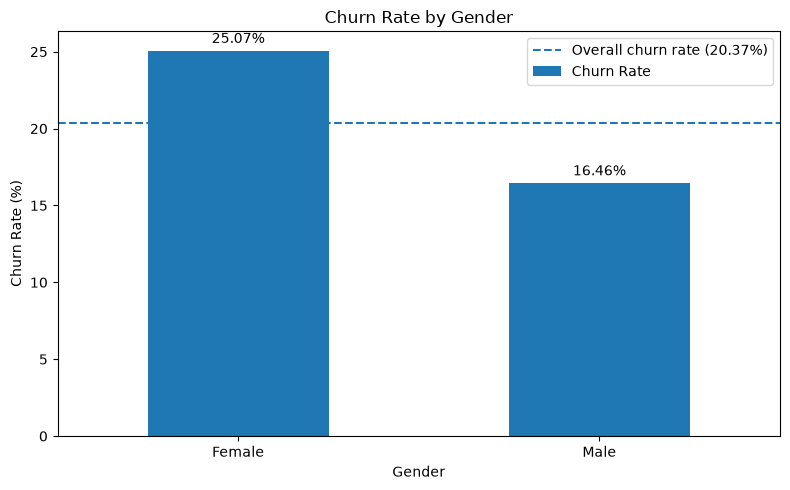

In [130]:
# Visualise churn rate by gender

plt.figure(figsize=(8, 5))

ax = gender_churn["Churn Rate"].plot(kind="bar")

plt.axhline(
    overall_churn_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall churn rate ({overall_churn_rate:.2f}%)"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend()

# Add churn rate labels
for i, value in enumerate(gender_churn["Churn Rate"]):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_rate_by_gender.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 5.2 Geography-Age Interaction

The interaction between geography and age segment is examined to determine whether age-related churn patterns differ across France, Germany, and Spain. Churn rates are calculated for each geography-age combination to identify customer groups with particularly high or low levels of attrition.

In [131]:
# Calculate churn rate by geography and age segment

geo_age_churn = (
    df_clean.groupby(
        ["Geography", "AgeSegment"],
        observed=True
    )["Exited"]
    .mean()
    .mul(100)
    .round(2)
)

print("Churn rate by geography and age segment:")
print(geo_age_churn)

Churn rate by geography and age segment:
Geography  AgeSegment
France     Under 30       5.20
           30-45         11.87
           46-60         45.79
           60+           19.91
Germany    Under 30      12.63
           30-45         25.30
           46-60         67.33
           60+           38.94
Spain      Under 30       7.94
           30-45         12.52
           46-60         40.66
           60+           20.83
Name: Exited, dtype: float64


In [132]:
# Create a matrix for easier comparison

geo_age_matrix = geo_age_churn.unstack()

print("Geography-age churn matrix:")
print(geo_age_matrix)

Geography-age churn matrix:
AgeSegment  Under 30  30-45  46-60    60+
Geography                                
France          5.20  11.87  45.79  19.91
Germany        12.63  25.30  67.33  38.94
Spain           7.94  12.52  40.66  20.83


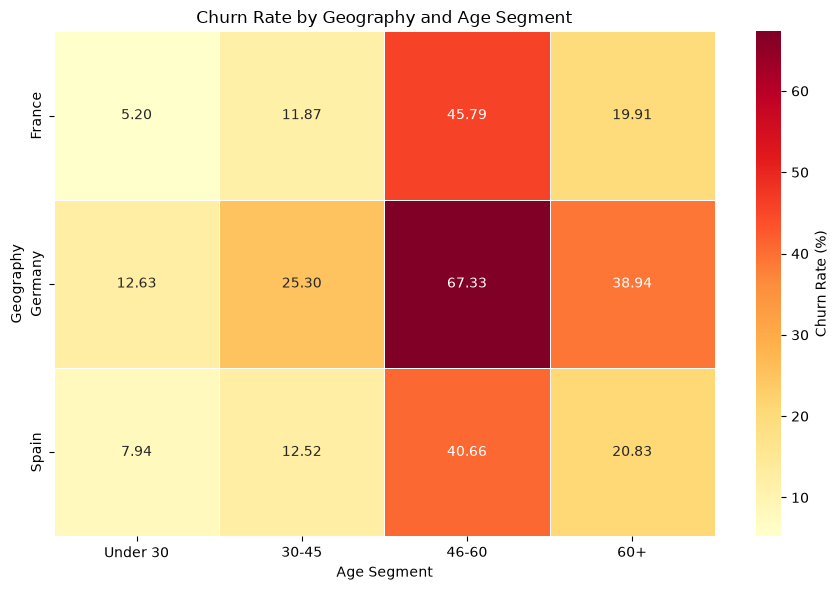

In [134]:
# Visualise geography-age churn interaction

plt.figure(figsize=(9, 6))

sns.heatmap(
    geo_age_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"}
)

plt.title("Churn Rate by Geography and Age Segment")
plt.xlabel("Age Segment")
plt.ylabel("Geography")

plt.tight_layout()
plt.savefig(
    "../outputs/churn_rate_by_geography_age.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 5.3 Financial Stability vs Churn

Financial characteristics are examined to assess whether customer financial position is associated with churn. Balance segments are compared by churn rate, while estimated salary and account balance are considered together to identify potential differences in financial profiles between churned and retained customers.

In [137]:
# Compare churn rate across balance segments
print(f"Overall churn rate: {overall_churn_rate:.2f}%")
print("\nChurn rate by balance segment:")
print(balance_churn["Churn Rate"])

Overall churn rate: 20.37%

Churn rate by balance segment:
BalanceSegment
Zero Balance    13.82
Low Balance     20.58
High Balance    25.23
Name: Churn Rate, dtype: float64


Financial stability is examined through account balance segments to assess whether churn varies according to customers' balance position. The analysis compares churn rates across zero-balance, low-balance, and high-balance customers.

The results indicate that churn increases across the balance categories:

- Balance Segment	        - Churn Rate
- Zero Balance	            - 13.82%
- Low Balance	            - 20.58%
- High Balance	            - 25.23%

The results suggest that customers with higher account balances have a higher observed churn rate in this dataset. This finding is particularly relevant to the high-value customer analysis in Section 6, where high-balance churners are examined in greater detail.

Important distinction

This is not a new analysis. We're formally documenting the financial-stability finding that we already established in 4.2.5.

# 6. High-Value Customer Churn Analysis

### 6.1 Identify High-Balance Churners

High-balance churners are identified as customers with an account balance of at least £100,000 who have exited the bank. The size and financial characteristics of this group are examined to assess the potential importance of high-balance customers within the overall churn population.

In [138]:
# Identify high-balance customers who have churned

high_balance_churners = df_clean[
    (df_clean["BalanceSegment"] == "High Balance") &
    (df_clean["Exited"] == 1)
].copy()

print("Number of high-balance churners:", len(high_balance_churners))

Number of high-balance churners: 1211


In [139]:
# Summarise the financial profile of high-balance churners

high_balance_summary = high_balance_churners[
    ["Balance", "EstimatedSalary"]
].describe().round(2)

print("Financial profile of high-balance churners:")
print(high_balance_summary)

Financial profile of high-balance churners:
         Balance  EstimatedSalary
count    1211.00          1211.00
mean   131700.82        100102.26
std     23089.29         58146.83
min    100032.52            11.58
25%    114533.66         49549.56
50%    127209.00        101240.08
75%    143948.61        150677.92
max    250898.09        199808.10


In [141]:
# Calculate total balance held by high-balance churners

total_high_balance_churn = high_balance_churners["Balance"].sum()

average_high_balance_churn = high_balance_churners["Balance"].mean()

median_high_balance_churn = high_balance_churners["Balance"].median()

print(
    f"Total balance held by high-balance churners: "
    f"{total_high_balance_churn:,.2f}"
)

print(
    f"Average balance of high-balance churners: "
    f"{average_high_balance_churn:,.2f}"
)

print(
    f"Median balance of high-balance churners: "
    f"{median_high_balance_churn:,.2f}"
)

Total balance held by high-balance churners: 159,489,691.00
Average balance of high-balance churners: 131,700.82
Median balance of high-balance churners: 127,209.00


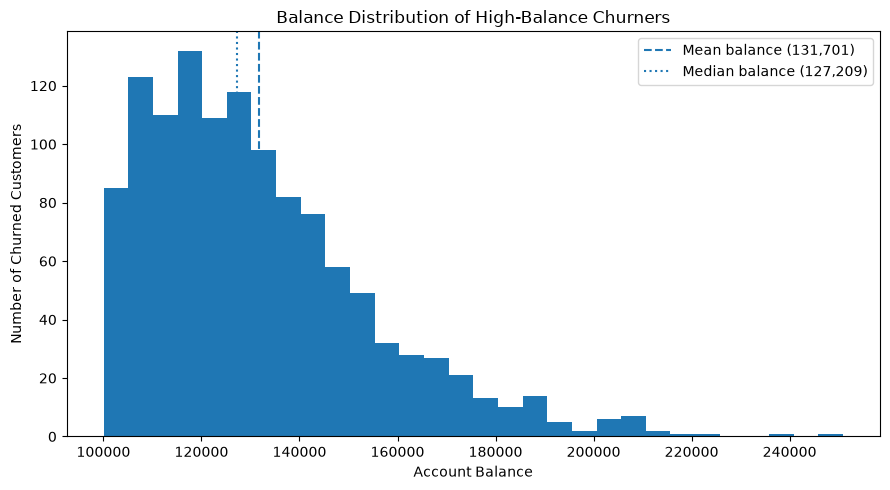

In [143]:
# Visualise balance distribution among high-balance churners

plt.figure(figsize=(9, 5))

plt.hist(
    high_balance_churners["Balance"],
    bins=30
)

plt.axvline(
    high_balance_churners["Balance"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"Mean balance ({high_balance_churners['Balance'].mean():,.0f})"
)

plt.axvline(
    high_balance_churners["Balance"].median(),
    linestyle=":",
    linewidth=1.5,
    label=f"Median balance ({high_balance_churners['Balance'].median():,.0f})"
)

plt.title("Balance Distribution of High-Balance Churners")
plt.xlabel("Account Balance")
plt.ylabel("Number of Churned Customers")
plt.legend()

plt.tight_layout()
plt.savefig(
    "../outputs/balance_distribution_high_balance_churners.png", dpi=300, bbox_inches="tight"
)

plt.show()

### 6.2 Salary vs Balance Churn Patterns

The relationship between estimated salary and account balance is examined among churned customers to identify potential financial patterns associated with high-value customer attrition. The analysis focuses on whether customers with higher balances also exhibit distinct salary characteristics.

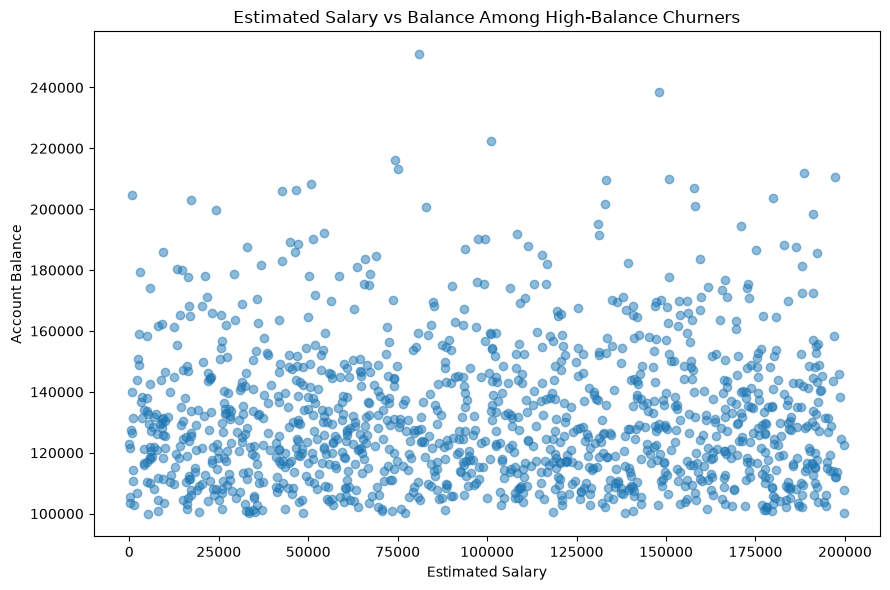

In [146]:
# Examine salary and balance relationship among churned customers

plt.figure(figsize=(9, 6))

plt.scatter(
    high_balance_churners["EstimatedSalary"],
    high_balance_churners["Balance"],
    alpha=0.5
)

plt.title("Estimated Salary vs Balance Among High-Balance Churners")
plt.xlabel("Estimated Salary")
plt.ylabel("Account Balance")

plt.tight_layout()
plt.savefig(
    "../outputs/salary_vs_balance_high_balance_churners.png", dpi=300, bbox_inches="tight"
)

plt.show()

In [148]:
# Calculate Pearson correlation between estimated salary and balance
# The Pearson correlation coefficient is calculated to quantify the linear relationship between estimated salary and account balance among high-balance churners. 
# This complements the scatter plot by providing a numerical measure of the strength and direction of the relationship.

salary_balance_correlation = (
    high_balance_churners["EstimatedSalary"]
    .corr(high_balance_churners["Balance"])
)

print(
    f"Pearson correlation between Estimated Salary and Balance: "
    f"{salary_balance_correlation:.4f}"
)

Pearson correlation between Estimated Salary and Balance: 0.0123


A correlation of 0.0123 is extremely close to zero.

This means that among high-balance churners, there is essentially no linear relationship between Estimated Salary and Account Balance.

- A higher estimated salary does not correspond to a systematically higher account balance.
- Customers with relatively low salaries can still hold very high balances.
- Customers with high salaries can also have balances across a wide range.
- Therefore, salary alone does not appear to explain the balance levels of high-balance churners.

In [149]:
# Create salary quartiles among high-balance churners

high_balance_churners["SalaryQuartile"] = pd.qcut(
    high_balance_churners["EstimatedSalary"],
    q=4,
    labels=["Q1 - Lowest", "Q2", "Q3", "Q4 - Highest"]
)

salary_quartile_profile = (
    high_balance_churners
    .groupby("SalaryQuartile", observed=True)
    .agg(
        Customers=("Balance", "count"),
        AverageSalary=("EstimatedSalary", "mean"),
        AverageBalance=("Balance", "mean"),
        MedianBalance=("Balance", "median")
    )
    .round(2)
)

print("Salary quartile profile of high-balance churners:")
print(salary_quartile_profile)

Salary quartile profile of high-balance churners:
                Customers  AverageSalary  AverageBalance  MedianBalance
SalaryQuartile                                                         
Q1 - Lowest           303       24921.76       130687.66      126345.55
Q2                    303       73923.56       132752.33      127475.24
Q3                    302      126435.48       131295.89      126880.94
Q4 - Highest          303      175215.16       132066.05      128140.17


### 6.3 Quantify Revenue Risk from Churn

Potential financial exposure associated with customer churn is quantified using the account balance of churned high-balance customers. As the dataset does not contain customer revenue, profitability, fees, or lifetime value, balance exposure is used as a proxy rather than interpreting the calculated amount as actual lost revenue.

In [151]:
# Calculate balance exposure associated with all churned customers

churned_customers = df_clean[df_clean["Exited"] == 1].copy()

total_churned_balance = churned_customers["Balance"].sum()

average_churned_balance = churned_customers["Balance"].mean()

median_churned_balance = churned_customers["Balance"].median()

print(
    f"Total balance associated with churned customers: "
    f"{total_churned_balance:,.2f}"
)

print(
    f"Average balance of churned customers: "
    f"{average_churned_balance:,.2f}"
)

print(
    f"Median balance of churned customers: "
    f"{median_churned_balance:,.2f}"
)

Total balance associated with churned customers: 185,588,094.63
Average balance of churned customers: 91,108.54
Median balance of churned customers: 109,349.29


In [152]:
# Calculate the share of churned balance exposure from high-balance churners

high_balance_exposure_share = (
    total_high_balance_churn /
    total_churned_balance
) * 100

print(
    f"High-balance churners' share of total churned balance: "
    f"{high_balance_exposure_share:.2f}%"
)

High-balance churners' share of total churned balance: 85.94%


### 6.3.1 Balance Exposure by Customer Group

The total account balance associated with high-balance churners is compared with the balance associated with other churned customers. This illustrates the concentration of financial exposure within the high-balance churner population.

In [153]:
# Compare balance exposure between high-balance churners and other churned customers

other_churned_balance = (
    total_churned_balance -
    total_high_balance_churn
)

balance_exposure_comparison = pd.Series({
    "High-Balance Churners": total_high_balance_churn,
    "Other Churned Customers": other_churned_balance
})

print("Balance exposure by customer group:")
print(balance_exposure_comparison.round(2))

print(
    f"\nTotal balance exposure: "
    f"{balance_exposure_comparison.sum():,.2f}"
)

Balance exposure by customer group:
High-Balance Churners      1.594897e+08
Other Churned Customers    2.609840e+07
dtype: float64

Total balance exposure: 185,588,094.63


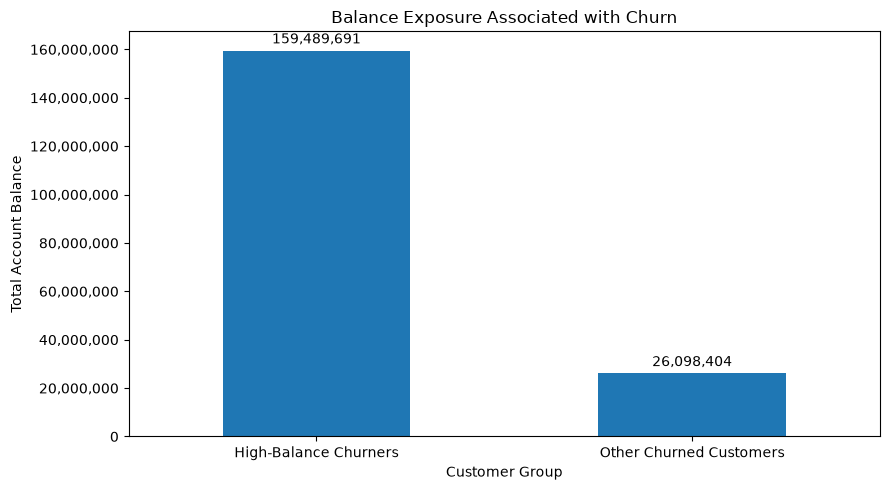

In [156]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(9, 5))

ax = balance_exposure_comparison.plot(kind="bar")

plt.title("Balance Exposure Associated with Churn")
plt.xlabel("Customer Group")
plt.ylabel("Total Account Balance")
plt.xticks(rotation=0)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

for i, value in enumerate(balance_exposure_comparison):
    ax.text(
        i,
        value + 3000000,
        f"{value:,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    "../outputs/balance_exposure_associated_with_churn.png", dpi=300, bbox_inches="tight"
)

plt.show()

# KPIs & Post-Analysis: Consolidated Findings Summary

### Consolidated Findings Summary 

The key findings from the customer segmentation and churn analysis are consolidated into a single summary table. This table provides a consistent reference for the major churn indicators, segment-level patterns, customer profiles, and high-value customer risk identified throughout the analysis.

In [160]:
# Create a consolidated summary of the key analytical findings

findings_summary = pd.DataFrame({
    "Analysis Area": [
        "Overall Churn",
        "Geography",
        "Age",
        "Gender",
        "Credit Score",
        "Tenure",
        "Balance",
        "Customer Engagement",
        "Geography × Age",
        "High-Balance Churners",
        "Churn Balance Exposure",
        "High-Balance Exposure Share",
        "Salary × Balance"
    ],
    "Key Finding": [
        "Overall churn rate",
        "Germany has the highest churn rate",
        "46-60 age group has the highest churn rate",
        "Female customers have higher churn",
        "Low credit score has the highest churn rate",
        "Tenure shows limited variation in churn",
        "High-balance customers have the highest churn rate",
        "Inactive customers are disproportionately represented among churners",
        "Germany + 46-60 has the highest combined churn rate",
        "1,211 high-balance customers churned",
        "Total balance associated with churned customers",
        "Share of churned balance exposure from high-balance churners",
        "Very weak relationship between salary and balance"
    ],
    "Value": [
        "20.37%",
        "32.44%",
        "51.12%",
        "25.07%",
        "22.02%",
        "New: 21.14%",
        "25.23%",
        "63.92%",
        "67.33%",
        "1,211 customers",
        "185,588,094.63",
        "85.94%",
        "Pearson r = 0.0123"
    ]
})

print("Consolidated Analytical Findings:")
print(findings_summary.to_string(index=False))

# Save the consolidated analytical findings

findings_summary.to_csv(
    "../outputs/tables/consolidated_analytical_findings.csv",
    index=False
)

print("Consolidated findings table saved successfully.")

Consolidated Analytical Findings:
              Analysis Area                                                          Key Finding              Value
              Overall Churn                                                   Overall churn rate             20.37%
                  Geography                                   Germany has the highest churn rate             32.44%
                        Age                           46-60 age group has the highest churn rate             51.12%
                     Gender                                   Female customers have higher churn             25.07%
               Credit Score                          Low credit score has the highest churn rate             22.02%
                     Tenure                              Tenure shows limited variation in churn        New: 21.14%
                    Balance                   High-balance customers have the highest churn rate             25.23%
        Customer Engagement Inactive c